In [1]:
# %%
# ============================================================
# 🌐 CNN Baseline — AIA + HMI (Fair Comparison with FlareEUV)
# ============================================================
# • Input: 13-channel (8×AIA + 5×HMI) averaged, north-up full-disk maps
# • Target: [EUV_T0, EUV_T+1, EUV_T+2]  (Level-3 6.5 nm)
# • SAME TRAINING PIPELINE as FlareEUV:
#   - Zero-mean target scaling (1e-4)
#   - Global per-channel standardization
#   - LOFO evaluation (one flare held out)
#   - MPS/CUDA/CPU aware .to(device, dtype=torch.float32)
#   - Weighted MSE loss: [0.6, 0.3, 0.1]
#   - Per-flare Pearson r + Global MAE/R² + Figure plots
# ============================================================

import os, warnings, numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models    # still needed for GradCAM hooks later
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import sys

print("Torch:", torch.__version__, " | Numpy:", np.__version__, " | Python:", sys.version)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = (
    "mps" if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("✅ Device:", device)

# ---------------- Config ----------------
DATA_DIR = "preprocessed_data"
IMG_CHANNELS = 13
EPOCHS = 80
BATCH_SIZE = 4
LR = 5e-4
WEIGHT_DECAY = 1e-4
SCHED_STEP, SCHED_GAMMA = 20, 0.5
TARGET_SCALE = 1e-4
LOSS_WEIGHTS = torch.tensor([0.6, 0.3, 0.1], dtype=torch.float32)


Torch: 2.8.0  | Numpy: 2.2.6  | Python: 3.11.13 (main, Jun  5 2025, 08:21:08) [Clang 14.0.6 ]
✅ Device: mps


In [2]:
# %%
# ============================================================
# 📂 Load Dataset (Same as FlareEUV — FAIR Comparison)
# ============================================================

X = np.load(os.path.join(DATA_DIR, "X_aiahmi.npy"))   # shape: (N, 13, H, W)
Y = np.load(os.path.join(DATA_DIR, "Y_aiahmi.npy"))   # shape: (N, 3)
print(f"Loaded AIA+HMI dataset → X: {X.shape}, Y: {Y.shape}")

# Zero-mean target scaling by 1e-4 (same as FlareEUV / HMI-only / AIA-only)
Y_scaled = (Y - Y.mean(axis=0)) / TARGET_SCALE

# Flare IDs for LOFO — must match preprocessing order!
flare_ids = pd.read_csv("flare_euv_targets_3day.csv")["flare_id"].tolist()
assert len(flare_ids) == len(X), "Mismatch between X and Y lengths vs CSV."


Loaded AIA+HMI dataset → X: (10, 13, 128, 128), Y: (10, 3)


In [3]:
# %%
# ============================================================
# 🔧 Dataset + Global Channel Standardization
# ============================================================

def compute_global_stats(X):
    """Return (means[13], stds[13]) across all flares & pixels per channel."""
    C = X.shape[1]
    means = np.array([X[:, c].mean() for c in range(C)], dtype=np.float32)
    stds  = np.array([X[:, c].std() + 1e-6 for c in range(C)], dtype=np.float32)
    return means, stds

GLOBAL_MEAN, GLOBAL_STD = compute_global_stats(X)
print("Channel means:", np.round(GLOBAL_MEAN, 6))
print("Channel stds :", np.round(GLOBAL_STD, 6))

class FlareDataset(Dataset):
    def __init__(self, X, Y, mean, std):
        self.X, self.Y = X.astype(np.float32), Y.astype(np.float32)
        self.mean, self.std = mean.astype(np.float32), std.astype(np.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        x = (self.X[idx] - self.mean[:, None, None]) / self.std[:, None, None]
        y = self.Y[idx]
        return torch.tensor(x), torch.tensor(y)


Channel means: [0.492324 0.734472 1.483596 1.549228 1.422248 0.945892 0.638279 1.109805
 1.128177 0.960289 1.114862 1.740735 1.246195]
Channel stds : [0.220551 0.352413 0.445733 0.433431 0.430514 0.486787 0.308068 0.561247
 0.768079 0.654871 0.758421 1.101902 0.767875]


In [4]:
class TinyBaselineCNN(nn.Module):
    def __init__(self, in_channels=13, out_features=3):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, kernel_size=3, padding=1),  # ↓ 16 → 8 channels
            nn.ReLU(),
            nn.MaxPool2d(4),    # ↓ 128×128 → 32×32

            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # ↓ 32 → 16 channels
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # → 16 features ONLY
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16, out_features)   # 16 → 3  (ONLY 51 params!)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


In [ ]:
# dont use

class TinyBaselineCNN(nn.Module):
    def __init__(self, in_channels=13, out_features=3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),     # 13×128×128 → 16×64×64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))  # → 32 features total
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, out_features)  # ONLY 32 → 3
        )

    def forward(self, x):
        return self.fc(self.conv(x))


In [5]:
cnn_model = TinyBaselineCNN(in_channels=IMG_CHANNELS, out_features=3)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"🧠 CNN Parameters: {cnn_params:,}")


🧠 CNN Parameters: 2,163


In [6]:
# %%
# ============================================================
# 🏋️ Training / Evaluation (Works for TinyBaselineCNN)
# ============================================================

def loss_fn_weighted(pred, target, weights=LOSS_WEIGHTS):
    diff2 = (pred - target) ** 2
    return (diff2 * weights.to(pred.device)).mean()

def train_one(model, loader):
    model = model.to(device, dtype=torch.float32)
    opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=SCHED_STEP, gamma=SCHED_GAMMA)

    best, best_state, patience = float("inf"), None, 0

    for ep in range(EPOCHS):
        model.train()
        batch_losses = []
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn_weighted(pred, yb)  # <-- fixed call
            loss.backward()
            opt.step()
            batch_losses.append(loss.detach().item())

        sched.step()
        print(f"Epoch {ep+1:03d}/{EPOCHS} | loss={np.mean(batch_losses):.6f}")

        # Early stopping
        if np.mean(batch_losses) < best - 1e-10:
            best = np.mean(batch_losses)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1
            if patience >= 20:
                print("⏹️  Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device, dtype=torch.float32)
            p  = model(xb)
            preds.extend(p.cpu().numpy())
            trues.extend(yb.cpu().numpy())

    # Undo scaling
    preds  = np.array(preds) * TARGET_SCALE + Y.mean(axis=0)
    trues_ = np.array(trues) * TARGET_SCALE + Y.mean(axis=0)

    mae = mean_absolute_error(trues_, preds)
    r, _ = pearsonr(trues_.ravel(), preds.ravel())
    return mae, r, preds, trues_


In [7]:
# %%
# ============================================================
# 🔁 LOFO Evaluation — TinyBaselineCNN (FAIR BASELINE)
# ============================================================

import os, numpy as np, csv

os.makedirs("results_lofo_tiny", exist_ok=True)   # separate folder
tiny_results = []   # store separately

print("\n========== Starting LOFO Evaluation — TinyBaselineCNN ==========")

for test_idx, test_flare in enumerate(flare_ids):
    print(f"\n🧪 TINY-CNN — Testing on held-out flare: {test_flare}")

    # Train/Test split
    train_mask = np.ones(len(X), dtype=bool)
    train_mask[test_idx] = False

    ds_tr = FlareDataset(X[train_mask], Y_scaled[train_mask], GLOBAL_MEAN, GLOBAL_STD)
    ds_va = FlareDataset(X[~train_mask], Y_scaled[~train_mask], GLOBAL_MEAN, GLOBAL_STD)

    tr_loader = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(ds_va, batch_size=1, shuffle=False)

    # 🔥 Use the TINY model only:
    model = TinyBaselineCNN(in_channels=IMG_CHANNELS, out_features=3).to(device)
    print("   🔧 Training TinyBaselineCNN ...")
    train_one(model, tr_loader)

    # --- Save model weights (optional, grad-cam etc.)
    model_path = f"results_lofo_tiny/{test_flare}_TINY_model.pth"
    torch.save(model.state_dict(), model_path)
    print(f"   💾 Saved model weights → {model_path}")

    # --- Evaluate ---
    mae, r, preds, trues = evaluate(model, va_loader)
    tiny_results.append((test_flare, mae, r, preds, trues))
    print(f"   📊 Tiny Fold — MAE={mae:.6e}, r={r:.3f}")

    # --- Save predictions ---
    npz_path = f"results_lofo_tiny/{test_flare}_TINY_preds.npz"
    np.savez(npz_path, flare=test_flare, preds=preds, trues=trues)
    print(f"   💾 Saved predictions → {npz_path}")

print("\n========== TINY-CNN LOFO COMPLETE ==========")
for fid, mae, r, _, _ in tiny_results:
    print(f"{fid:15s} | MAE={mae:.6e} | r={r:.3f}")

# --- Save summary CSV ---
summary_path = "results_lofo_tiny/TINY_summary.csv"
with open(summary_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["flare_id", "MAE", "r"])
    for fid, mae, r, _, _ in tiny_results:
        w.writerow([fid, f"{mae:.6e}", f"{r:.3f}"])

print(f"\n📁 Summary saved → {summary_path}")



========== Starting LOFO Evaluation — TinyBaselineCNN ==========

🧪 TINY-CNN — Testing on held-out flare: AR11158_M6.6
   🔧 Training TinyBaselineCNN ...
Epoch 001/80 | loss=0.026014
Epoch 002/80 | loss=0.029732
Epoch 003/80 | loss=0.022538
Epoch 004/80 | loss=0.023433
Epoch 005/80 | loss=0.017440
Epoch 006/80 | loss=0.020174
Epoch 007/80 | loss=0.012495
Epoch 008/80 | loss=0.018013
Epoch 009/80 | loss=0.011684
Epoch 010/80 | loss=0.014205
Epoch 011/80 | loss=0.011097
Epoch 012/80 | loss=0.013974
Epoch 013/80 | loss=0.013655
Epoch 014/80 | loss=0.010843
Epoch 015/80 | loss=0.010805
Epoch 016/80 | loss=0.010745
Epoch 017/80 | loss=0.010598
Epoch 018/80 | loss=0.012879
Epoch 019/80 | loss=0.010451
Epoch 020/80 | loss=0.010217
Epoch 021/80 | loss=0.010146
Epoch 022/80 | loss=0.010019
Epoch 023/80 | loss=0.015942
Epoch 024/80 | loss=0.010049
Epoch 025/80 | loss=0.015586
Epoch 026/80 | loss=0.015343
Epoch 027/80 | loss=0.009709
Epoch 028/80 | loss=0.013842
Epoch 029/80 | loss=0.009728
Epoch


=== TINY-CNN — Average Prediction Error (W/m²/nm) ===
 T₀=1.79e-05 | T₊₁=1.91e-05 | T₊₂=1.94e-05
✅ Saved: figures_tiny/TINY_horizon_error.pdf


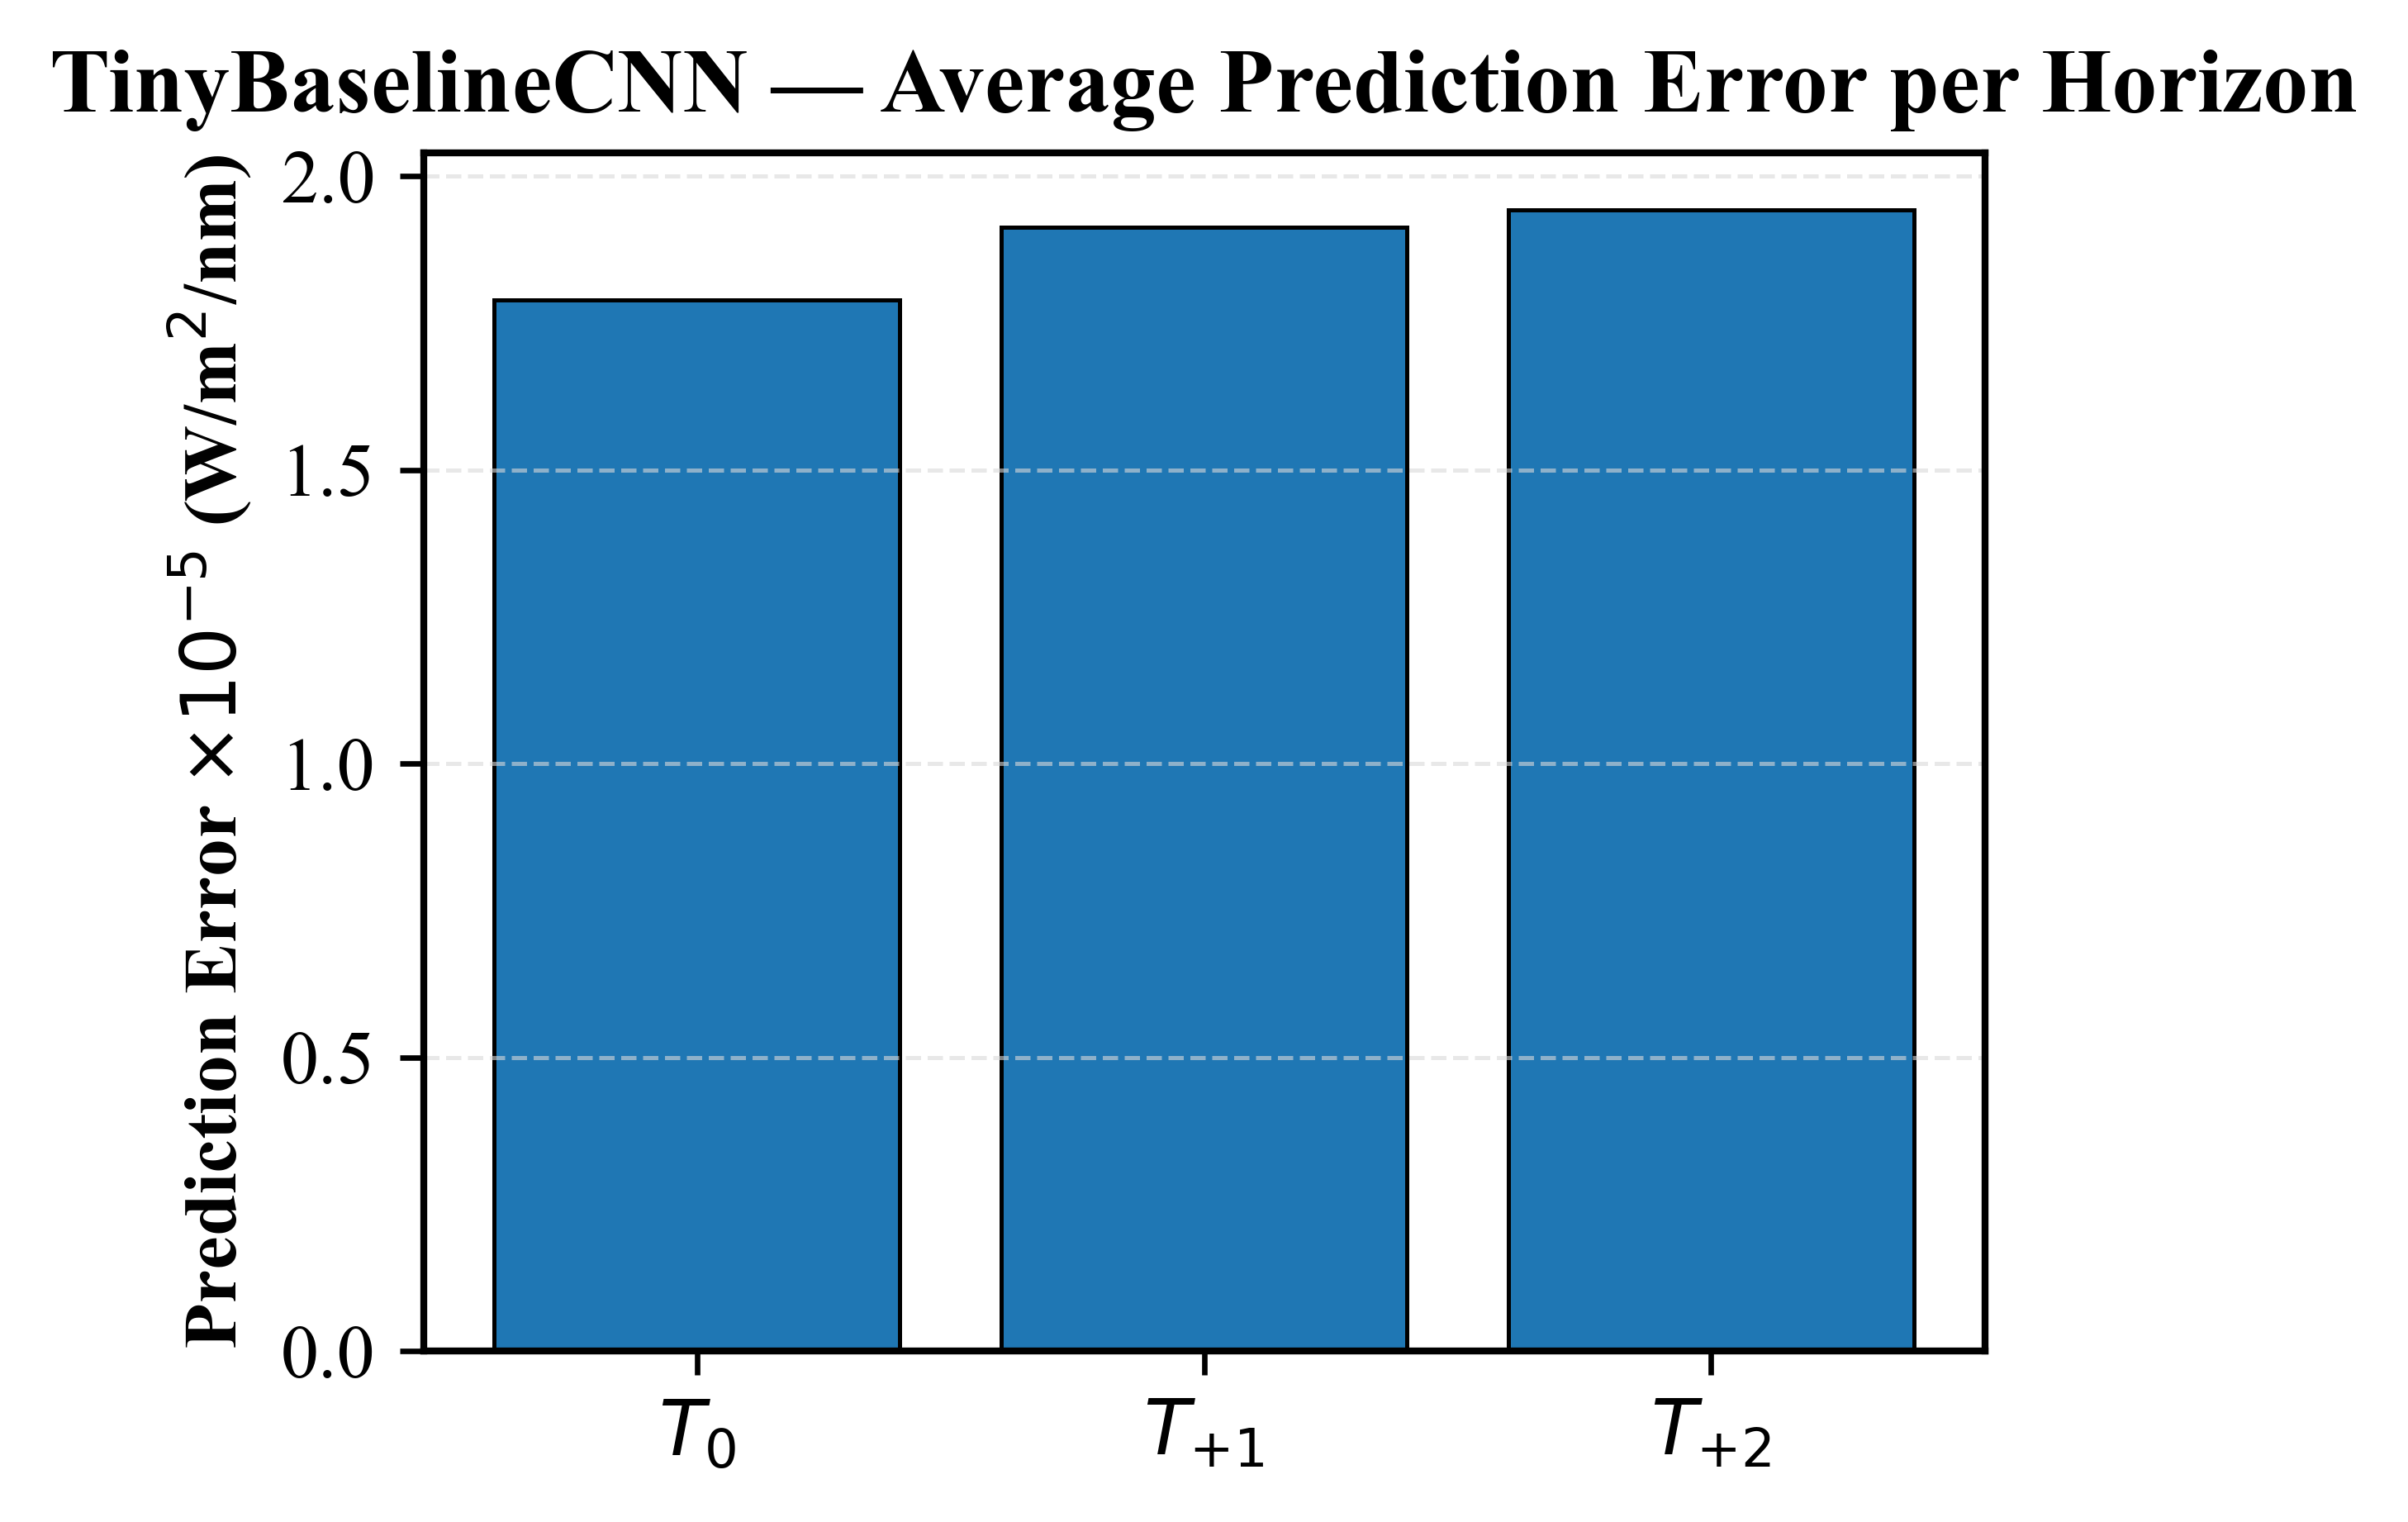

In [8]:
# %%
# ============================================================
# 📏 Horizon-wise Error — TinyBaselineCNN (IEEE Metric)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import os

# 🔁 USE *tiny_results* — NOT cnn_results / flare_results
errs = np.array([np.abs(p - t)[0] for _, _, _, p, t in tiny_results])  
avg_err = errs.mean(axis=0)

print("\n=== TINY-CNN — Average Prediction Error (W/m²/nm) ===")
print(f" T₀={avg_err[0]:.2e} | T₊₁={avg_err[1]:.2e} | T₊₂={avg_err[2]:.2e}")

# --- IEEE Plot Formatting ---
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.0,
    "grid.color": "0.85",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6
})

# --- Horizons ---
horizons = [r"$T_0$", r"$T_{+1}$", r"$T_{+2}$"]

plt.figure(figsize=(4.0, 3.2), dpi=600)
plt.bar(horizons, avg_err * 1e5, edgecolor="black", linewidth=0.6)

plt.ylabel(r"Prediction Error $\times10^{-5}$ (W/m$^{2}$/nm)", fontweight="bold")
plt.title("TinyBaselineCNN — Average Prediction Error per Horizon", fontweight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()

os.makedirs("figures_tiny", exist_ok=True)
plt.savefig("figures_tiny/TINY_horizon_error.pdf", dpi=600, bbox_inches="tight")
print("✅ Saved: figures_tiny/TINY_horizon_error.pdf")
plt.show()



--- Global Metrics (CNN Baseline) ---
Linear correction: y_true ≈ 1.27 * pred + -2.44e-05
Raw correlation (r)       = 0.91
Corrected correlation (r) = 0.91
Global R²                 = 0.783
Global MAE                = 7.68e-06 W/m²/nm
Global Relative Error     = 9.3%
📁 Saved: figures/CNN_raw_corrected.pdf


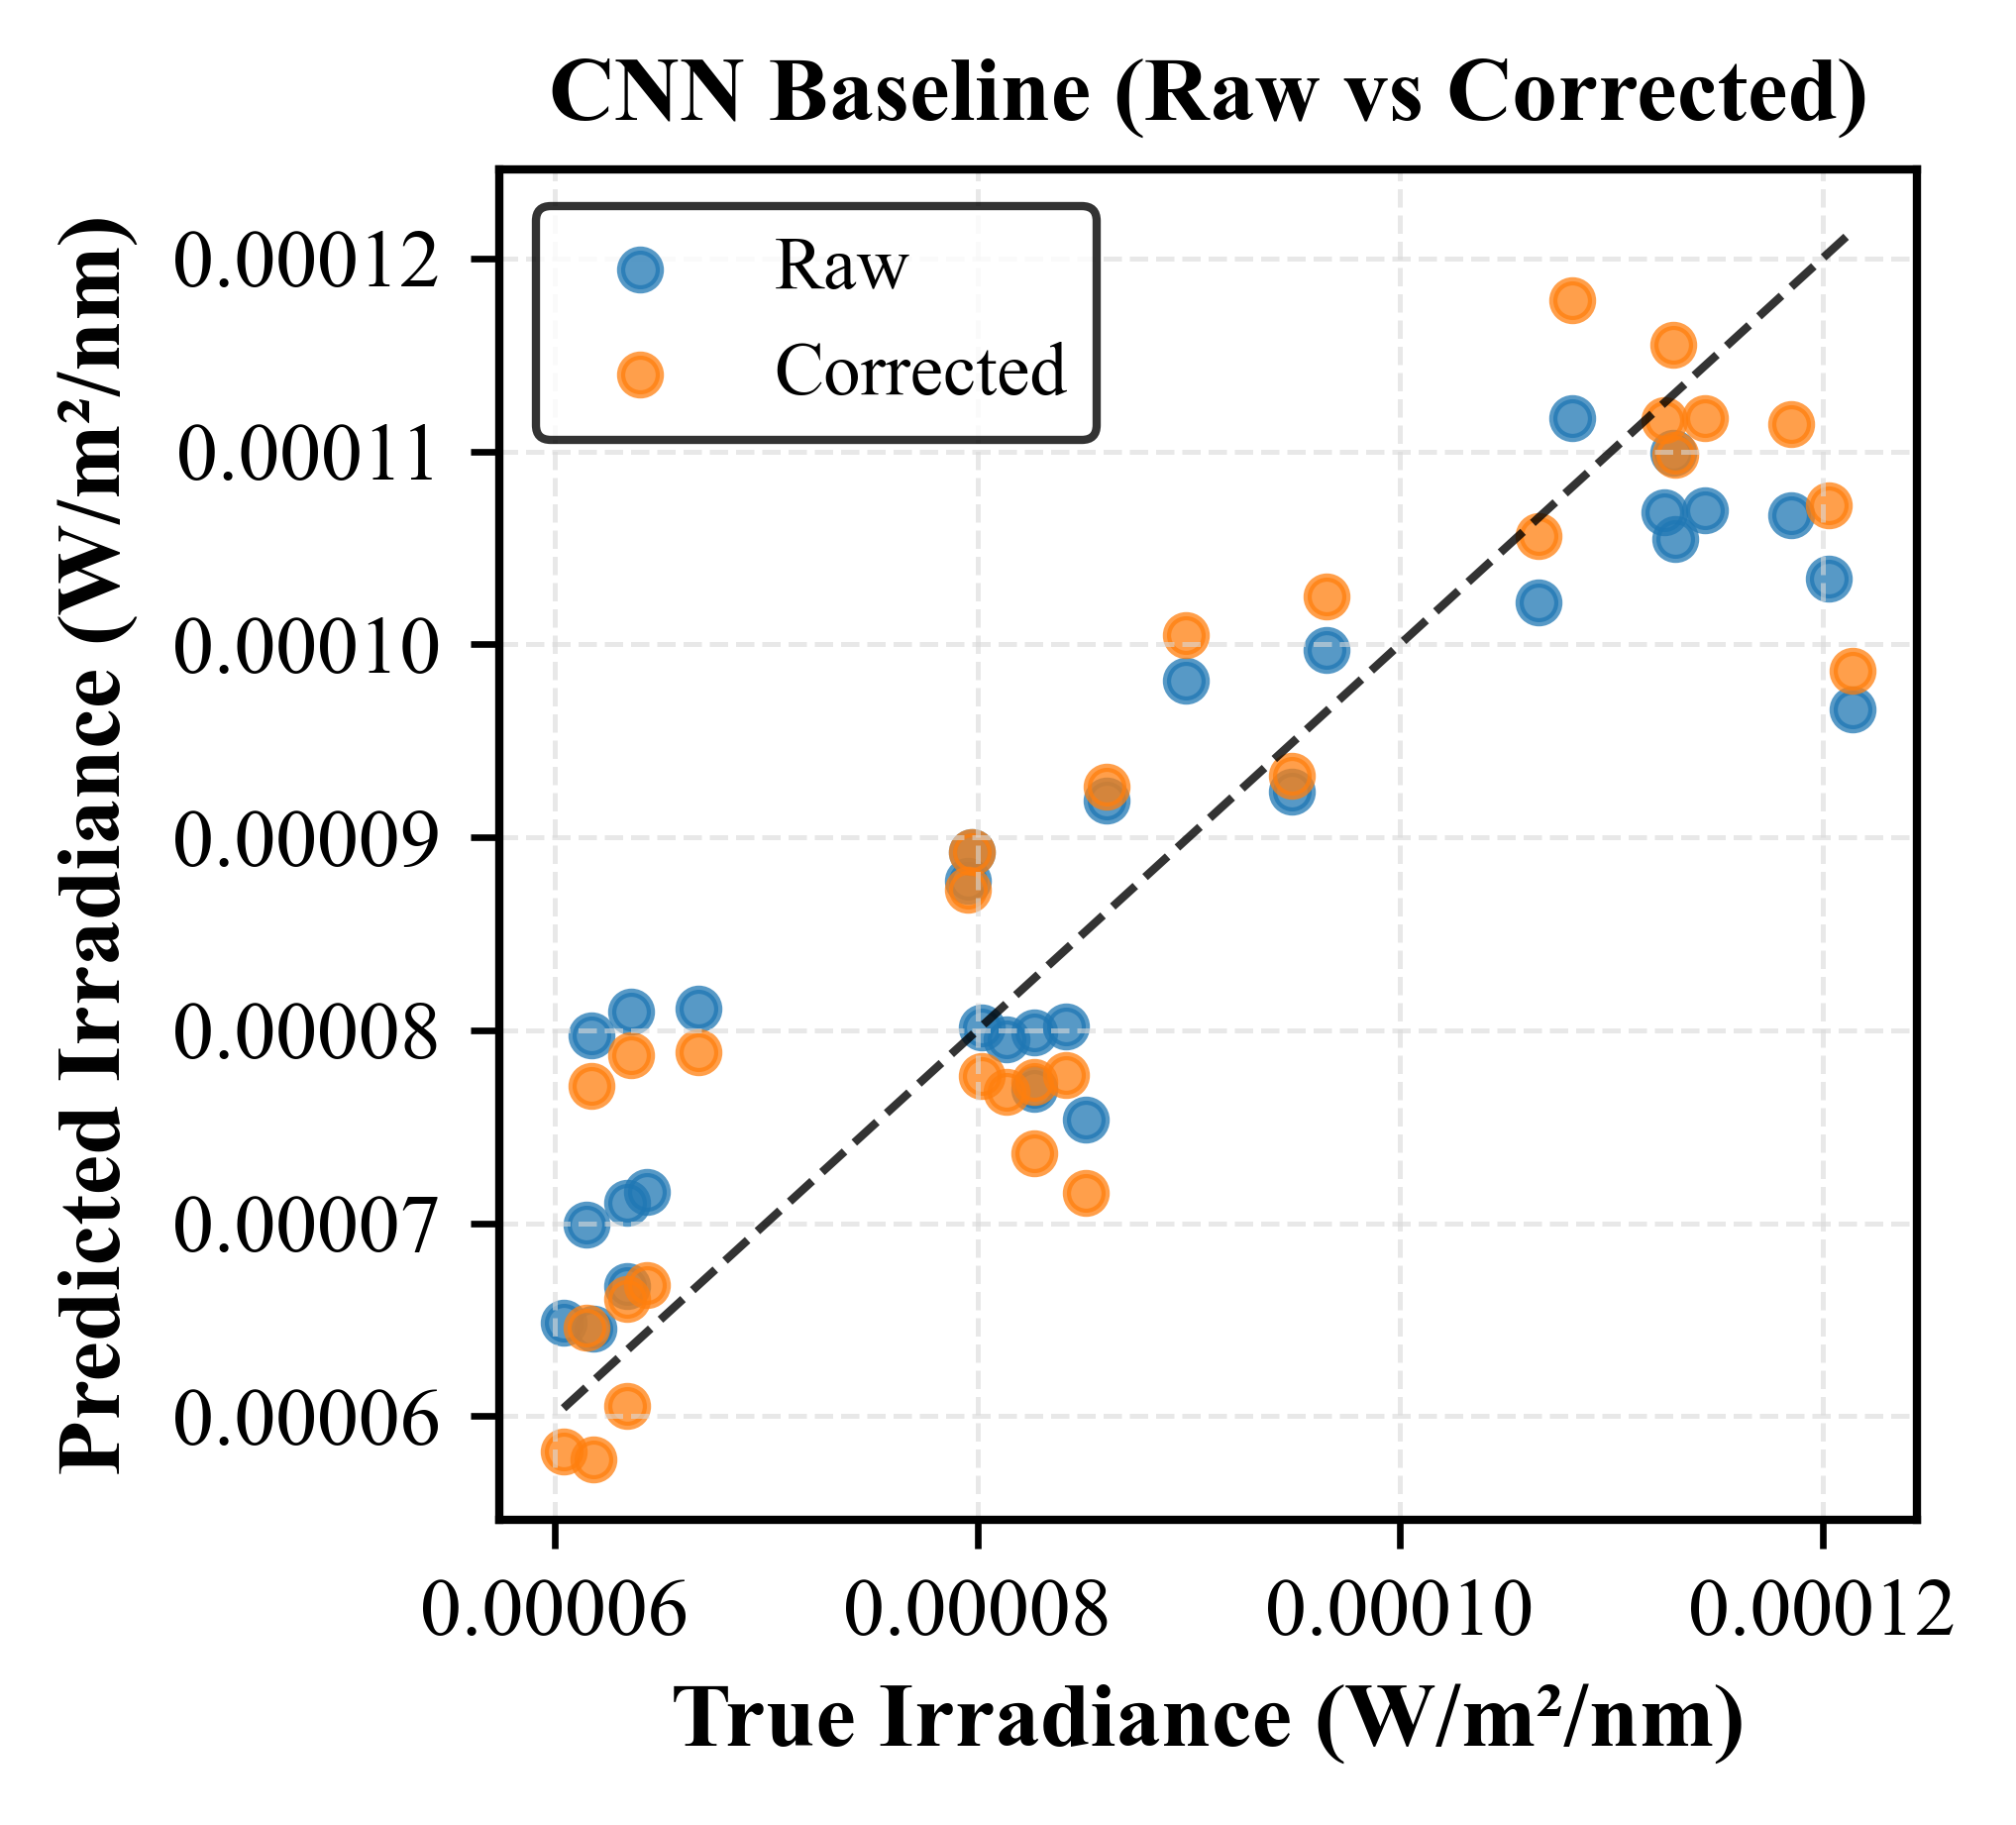

In [20]:
# %%
# ============================================================
# 📊 Global Metrics / Scatter — CNN BASELINE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# --- Flatten prediction / target arrays ---
pred_all = np.concatenate([np.array(p).reshape(-1, 3) for _, _, _, p, _ in cnn_results], axis=0)
true_all = np.concatenate([np.array(t).reshape(-1, 3) for _, _, _, _, t in cnn_results], axis=0)
pred_flat, true_flat = pred_all.ravel(), true_all.ravel()

# --- Linear correction fit ---
lr = LinearRegression().fit(pred_flat.reshape(-1, 1), true_flat)
corr_raw = np.corrcoef(true_flat, pred_flat)[0, 1]
corr_corr = np.corrcoef(true_flat, lr.predict(pred_flat.reshape(-1, 1)))[0, 1]
r2 = r2_score(true_flat, pred_flat)
mae = mean_absolute_error(true_flat, pred_flat)
rel_err = np.mean(np.abs((pred_flat - true_flat) / (true_flat + 1e-8)))

print("\n--- Global Metrics (CNN Baseline) ---")
print(f"Linear correction: y_true ≈ {lr.coef_[0]:.2f} * pred + {lr.intercept_:.2e}")
print(f"Raw correlation (r)       = {corr_raw:.2f}")
print(f"Corrected correlation (r) = {corr_corr:.2f}")
print(f"Global R²                 = {r2:.3f}")
print(f"Global MAE                = {mae:.2e} W/m²/nm")
print(f"Global Relative Error     = {rel_err*100:.1f}%")

# --- Plot Raw vs Corrected ---
plt.figure(figsize=(3.5, 3.2), dpi=600)
plt.scatter(true_flat, pred_flat, s=22, alpha=0.75, label="Raw")
plt.scatter(true_flat, lr.predict(pred_flat.reshape(-1, 1)),
            s=22, alpha=0.75, label="Corrected")

plt.plot([true_flat.min(), true_flat.max()],
         [true_flat.min(), true_flat.max()],
         "k--", lw=1, alpha=0.8)

plt.xlabel("True Irradiance (W/m²/nm)", fontweight="bold")
plt.ylabel("Predicted Irradiance (W/m²/nm)", fontweight="bold")
plt.title("CNN Baseline (Raw vs Corrected)", fontweight="bold")
plt.legend(edgecolor="black")
plt.grid(True, which="both", ls="--", lw=0.6, alpha=0.6)
plt.tight_layout()

# --- Save figure ---
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/CNN_raw_corrected.pdf", dpi=600, bbox_inches="tight")
print("📁 Saved: figures/CNN_raw_corrected.pdf")
plt.show()
